In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import json
import seaborn as sns
import warnings
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append("/home/iscb/wolfson/hagairavid/ligand_aligner")
from utils.loading import deserialize_nested_lists

In [2]:
# prefix = "2024-07-04_23-31-40_3083.csv"
# prefix = "2024-07-11_10-24-20_2720.csv"
prefix = "2024-07-17_16-01-08_3000.csv"
prefix = "2024-07-18_10-26-26_10000.csv"
prefix = "2024-07-30_10-18-28_500.csv"
# directory = "/home/iscb/wolfson/hagairavid/ligand_aligner/baseline_results/"
directory = "/home/iscb/wolfson/hagairavid/ligand_aligner/results/baseline_results/"
matching_files = [f for f in os.listdir(directory) if f.startswith(prefix)]

if matching_files:
    latest_file = max(matching_files, key=lambda x: os.path.getmtime(os.path.join(directory, x)))
    file_path = os.path.join(directory, latest_file)
    print("Latest file:", file_path)
else:
    print("No matching files found.")
df = pd.read_csv(file_path)


df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, str) and x.startswith('[') and x.endswith(']')).any():
        df[col] = df[col].apply(lambda x: json.loads(x))
        df[col] = df[col].apply(lambda x: deserialize_nested_lists(x, col))

Latest file: /home/iscb/wolfson/hagairavid/ligand_aligner/results/baseline_results/2024-07-30_10-18-28_500.csv


In [3]:
with_trans = df[df['n_transformations'] > 0]
with_trans.shape

(419, 38)

In [4]:
with_trans['found_dali'] = with_trans['DaliAligner_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_tm'] = with_trans['TMaligner_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_bbs'] = with_trans['HardBBS_rotations'].apply(lambda x: len(x) > 0)
with_trans['found_HardBBSRansac'] = with_trans['HardBBSRansac_rotations'].apply(lambda x: len(x) > 0)
print(with_trans['found_dali'].value_counts())
print(with_trans['found_tm'].value_counts())
with_trans['found_all'] = with_trans['found_tm'] & with_trans['found_dali'] & with_trans['found_bbs'] & with_trans['found_HardBBSRansac']

found_dali
True     231
False    188
Name: count, dtype: int64
found_tm
True    419
Name: count, dtype: int64


/tmp/ipykernel_607519/3114550560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['found_dali'] = with_trans['DaliAligner_rotations'].apply(lambda x: len(x) > 0)
/tmp/ipykernel_607519/3114550560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['found_tm'] = with_trans['TMaligner_rotations'].apply(lambda x: len(x) > 0)
/tmp/ipykernel_607519/3114550560.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

## DALI

In [5]:
with_trans['only_tm'] = with_trans['found_tm'] &  with_trans['found_dali'] == False
with_trans['only_tm'].value_counts()

/tmp/ipykernel_607519/3181294601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['only_tm'] = with_trans['found_tm'] &  with_trans['found_dali'] == False


only_tm
False    231
True     188
Name: count, dtype: int64

23.62990171981353
7.195478111942372


/tmp/ipykernel_607519/2657027292.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['max_bbr'] = with_trans['bbr'].apply(find_max_in_sublists)


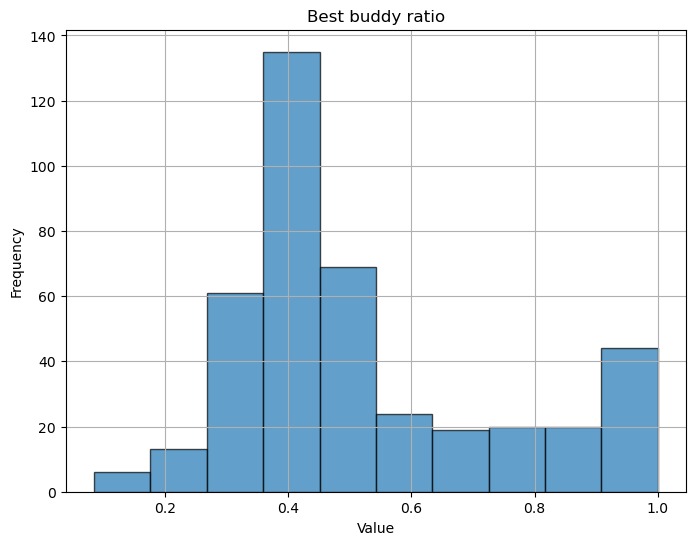

In [6]:
print(with_trans[with_trans['only_tm'] == True]['TMaligner_pocket_rmsd'].mean())
print(with_trans[with_trans['found_all'] == True]['TMaligner_pocket_rmsd'].mean())
def find_max_in_sublists(list_of_lists):
    try:
        return max([max(sublist) for sublist in list_of_lists])
    except:
        0

# Apply the function to the 'data' column and create a new column 'min_values'
with_trans['max_bbr'] = with_trans['bbr'].apply(find_max_in_sublists)
with_trans['max_bbr']
plt.figure(figsize=(8, 6))
plt.hist(with_trans['max_bbr'], bins=10, edgecolor='black', alpha=0.7)
plt.title('Best buddy ratio')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

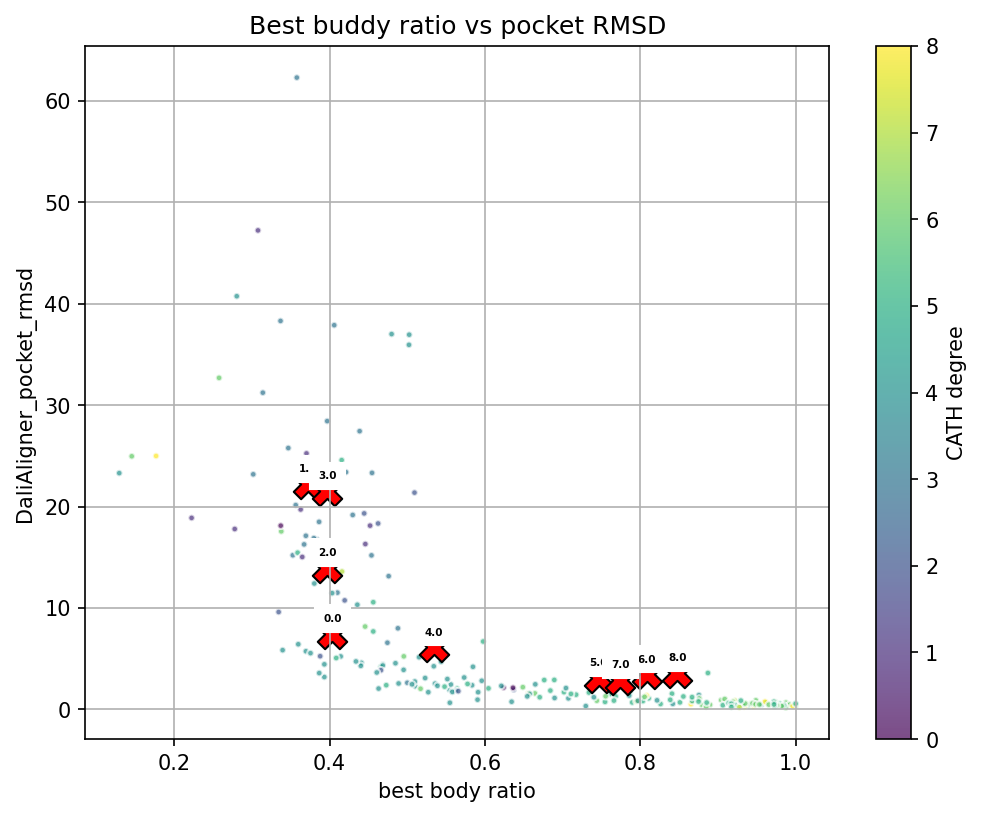

In [7]:
plt.figure(figsize=(8, 6), dpi=150)
scatter = plt.scatter(with_trans['max_bbr'], with_trans['DaliAligner_pocket_rmsd'], c=with_trans['cath_degree'], alpha=0.7, edgecolors='w', s=10)


# Overlay centroids
centroids = with_trans.groupby('cath_degree')[['max_bbr', 'DaliAligner_pocket_rmsd']].mean().reset_index()

# Annotate each centroid with its 'colors' value
for i, row in centroids.iterrows():
    plt.text(row['max_bbr'], row['DaliAligner_pocket_rmsd'] +1, f"{row['cath_degree']}", fontsize=5, ha='center', va='bottom', color='black', weight='bold', backgroundcolor='white')
plt.scatter(centroids['max_bbr'], centroids['DaliAligner_pocket_rmsd'], c='red', edgecolors='black', s=200, marker='X', label='Centroids')
plt.colorbar(scatter, label='CATH degree')

plt.title('Best buddy ratio vs pocket RMSD')
plt.xlabel('best body ratio')
plt.ylabel('DaliAligner_pocket_rmsd')
plt.grid(True)
plt.show()

## CATH degree and pocket RMSD correlation

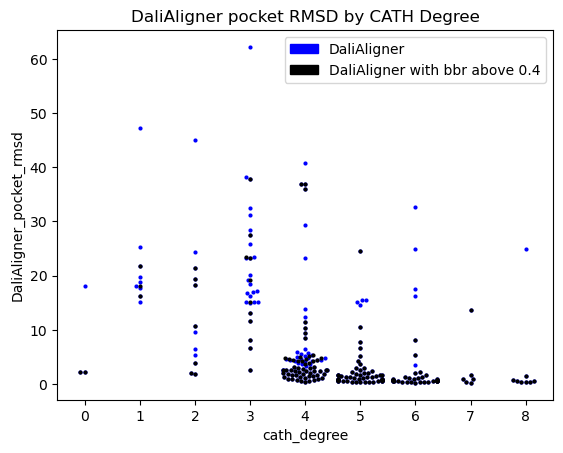

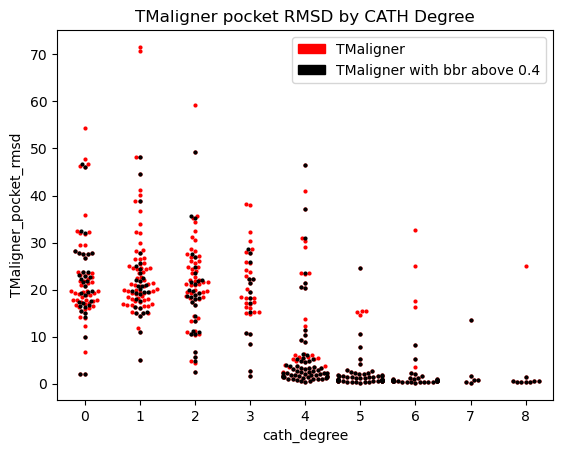

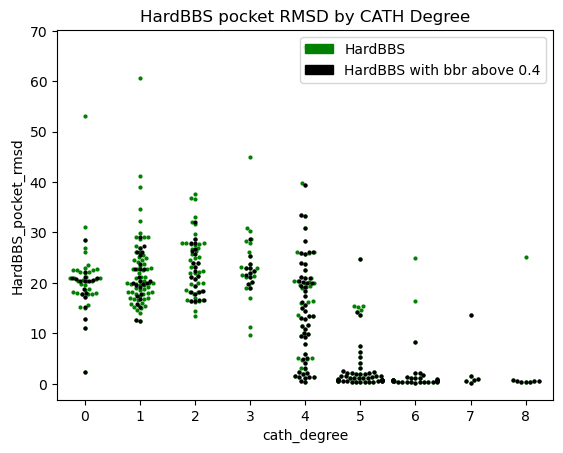

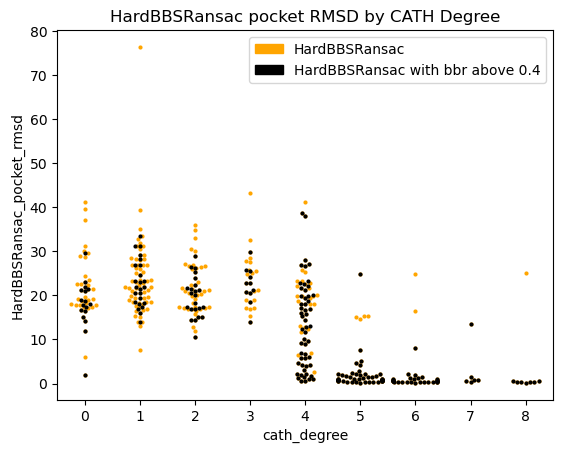

In [8]:
bbr_ratio = 0.4

for aligner_name, color in zip(['DaliAligner','TMaligner', 'HardBBS', "HardBBSRansac"], ['blue', 'red', 'green', 'orange']):   
    # color = "blue" if aligner_name == "DaliAligner" else "red"

    sns.swarmplot(data=with_trans, x="cath_degree", y=f"{aligner_name}_pocket_rmsd", size=3, label=aligner_name, color=color )
    sns.swarmplot(data=with_trans[ (with_trans['max_bbr'] > 0.4)], x="cath_degree", y=f"{aligner_name}_pocket_rmsd",color='black', size=3, label=aligner_name)

    plt.title(f"{aligner_name} pocket RMSD by CATH Degree")
    legend_handles = [
        Patch(color=color, label=aligner_name),
        Patch(color='black', label=f"{aligner_name} with bbr above {bbr_ratio}")
    ]

    plt.legend(handles=legend_handles)
    plt.show()

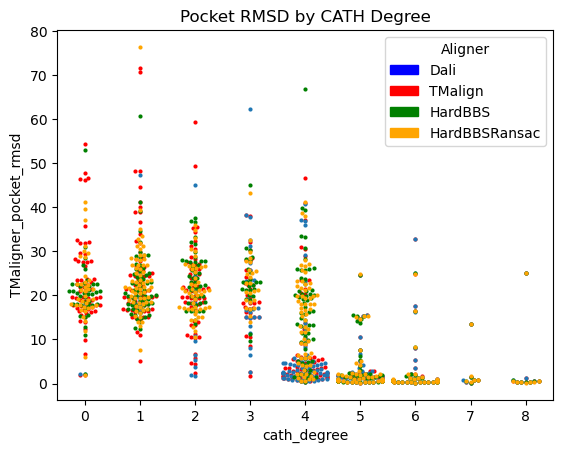

In [9]:
sns.swarmplot(data=with_trans, x="cath_degree", y="TMaligner_pocket_rmsd", size=3, label='TMalign', color='red')
sns.swarmplot(data=with_trans, x="cath_degree", y="DaliAligner_pocket_rmsd", size=3, label='Dali')
sns.swarmplot(data=with_trans, x="cath_degree", y="HardBBS_pocket_rmsd", size=3, label='HardBBS', color='green')
sns.swarmplot(data=with_trans, x="cath_degree", y="HardBBSRansac_pocket_rmsd", size=3, label='HardBBS', color='orange')
plt.title("Pocket RMSD by CATH Degree")
legend_handles = [
    Patch(color='blue', label='Dali'),
    Patch(color='red', label='TMalign'),
    Patch(color='green', label='HardBBS'),
    Patch(color='orange', label='HardBBSRansac')
]

plt.legend(handles=legend_handles, title='Aligner')

cath_degree
0     7.465956
1    20.002929
2     9.875207
3    20.030690
4     5.576839
5     2.735821
6     3.371208
7     2.468174
8     3.212224
Name: DaliAligner_pocket_rmsd, dtype: float64
cath_degree
0    17.054198
1    18.629605
2    17.334122
3    17.553305
4     6.946287
5     2.597642
6     3.368244
7     2.484047
8     2.932169
Name: TMaligner_pocket_rmsd, dtype: float64
cath_degree
0    20.707647
1    22.208039
2    23.589370
3    23.223991
4    15.739745
5     3.435154
6     2.221102
7     2.933023
8     3.523391
Name: HardBBS_pocket_rmsd, dtype: float64
cath_degree
0    21.334680
1    23.592966
2    21.397341
3    23.227995
4    14.421448
5     2.916704
6     2.220818
7     2.954888
8     3.488145
Name: HardBBSRansac_pocket_rmsd, dtype: float64


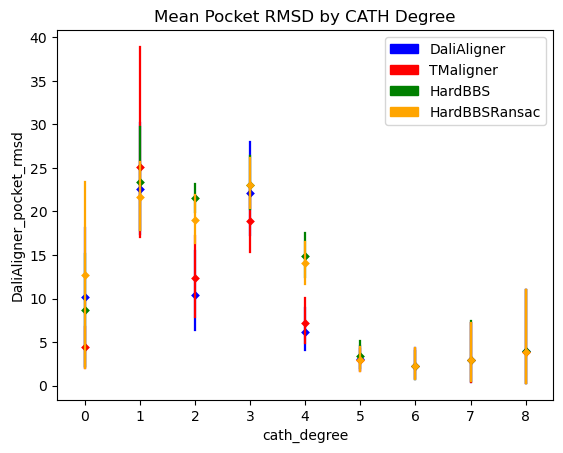

In [10]:
for aligner_name, color in zip(['DaliAligner','TMaligner', 'HardBBS', "HardBBSRansac"], ['blue', 'red', 'green', 'orange']):   
    print(df.groupby('cath_degree')[f"{aligner_name}_pocket_rmsd"].mean())
    sns.pointplot(
        data=with_trans[with_trans['found_all'] == True],
        x="cath_degree",
        y=f"{aligner_name}_pocket_rmsd",
        color=color,
        estimator='mean',
        markers='D',
        dodge=True,
        join=False,
        
        scale=0.6
    )

plt.title("Mean Pocket RMSD by CATH Degree")
median_legend_handles = [
    Patch(color='blue', linestyle='None', label='DaliAligner'),
    Patch(color='red', linestyle='None', label='TMaligner'),
    Patch(color='green', linestyle='None', label='HardBBS'),
    Patch(color='orange', linestyle='None', label='HardBBSRansac')

]
plt.legend(handles=median_legend_handles)
plt.show()

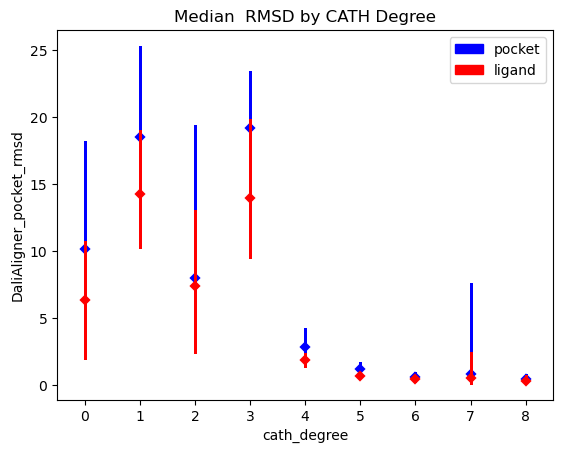

In [11]:
for domain in ['pocket_rmsd','ligand_rmsd']:
    color = "blue" if domain == "pocket_rmsd" else "red"

    sns.pointplot(
        data=with_trans[with_trans['found_all'] == True],
        x="cath_degree",
        y=f"DaliAligner_{domain}",
        color=color,
        estimator='median',
        markers='D',
        dodge=True,
        join=False,
        
        scale=0.8
    )

plt.title("Median  RMSD by CATH Degree")
median_legend_handles = [
    Patch(color='blue', linestyle='None', label='pocket'),
    Patch(color='red', linestyle='None', label='ligand')
]
plt.legend(handles=median_legend_handles)
plt.show()

In [12]:
with_trans['less_than_2'] = with_trans["DaliAligner_pocket_rmsd"] < 4
print((with_trans.groupby("cath_degree")["less_than_2"]).mean())
with_trans['less_than_2_tm'] = with_trans["TMaligner_pocket_rmsd"] < 4
(with_trans.groupby("cath_degree")["less_than_2_tm"]).mean()

cath_degree
0    0.031250
1    0.000000
2    0.050000
3    0.028571
4    0.552632
5    0.824561
6    0.842105
7    0.833333
8    0.777778
Name: less_than_2, dtype: float64


/tmp/ipykernel_607519/3209341117.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['less_than_2'] = with_trans["DaliAligner_pocket_rmsd"] < 4
/tmp/ipykernel_607519/3209341117.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['less_than_2_tm'] = with_trans["TMaligner_pocket_rmsd"] < 4


cath_degree
0    0.031250
1    0.000000
2    0.016667
3    0.057143
4    0.592105
5    0.842105
6    0.842105
7    0.833333
8    0.888889
Name: less_than_2_tm, dtype: float64

## Analays examples

In [24]:
dali_df = with_trans[(with_trans['cath_degree'] < 2) & (with_trans['n_transformations'] ==1) & (with_trans['n_transformations'] ==1)]
sorted_df = dali_df.sort_values(by='rmsd', ascending=True)

# Select the top 'h' rows
dali_df[['Ligand_ID', 'ref_protein', 'mov_protein', 'DaliAligner_pocket_rmsd', 'max_bbr', 'cath_degree', 'rmsd']].head(50)

,Ligand_ID,ref_protein,mov_protein,DaliAligner_pocket_rmsd,max_bbr,cath_degree,rmsd
1,ACO,1hm8,4xpl,NaN,0.084746,1,-1.0
10,GSH,2hqm,5ve5,NaN,0.402778,1,-1.0
20,PLP,1kl7,3wwh,NaN,0.408511,1,-1.0
21,PLP,1nrg,2ord,NaN,0.438356,0,-1.0
24,AKG,1llw,1unb,NaN,0.400794,1,-1.0
31,HEM,1a4e,2civ,NaN,0.457447,0,-1.0
34,2PG,1o98,3uwv,NaN,0.507246,1,-1.0
37,UD1,4r37,4wad,NaN,0.357143,0,-1.0
38,AKG,2ze3,4bu2,NaN,0.409910,1,-1.0
46,3PO,3tvl,4wyw,NaN,0.362903,0,-1.0
